In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from src.plot_style import configure_journal_style
from src.lifetime_kernels import survival_shifted_two_exp
from src.simulator import simulate_ensemble_N_grid
from src.transient_theory import compute_transient_pmf_and_moments
from src.steady_state_theory import compute_limiting_pmf_and_moments
from src.utils import compute_gate_equilibrium_weights


# parameters setup
Q = np.array([
    [-0.006, 0.005, 0.001],
    [0.050, -0.052, 0.002],
    [0.005, 0.002, -0.007],
], float)
lambdas = np.array([0.020, 0.003, 0.001], float)
L = 6000.0
W_means = np.array([5.0,  30.0, 240.0])
v_means = np.array([41.667, 33.333, 25.000])
Tterm_means = np.array([60.0,  60.0,  90.0])

T_max = 1200.0
dt = 1.0
t_grid = np.arange(0.0, T_max + dt, dt)
edges = t_grid
pi_stat = compute_gate_equilibrium_weights(Q)

Nmax = 30
P, p_nt, mean_from_p, mean_vec, pi0_used, norm_err = compute_transient_pmf_and_moments(
    Q=Q, lambdas=lambdas, L=L,
    W_means=W_means, v_means=v_means, Tterm_means=Tterm_means,
    t_grid=t_grid, Nmax=Nmax, pi0=pi_stat
)

R = 15000
R = 15000
rng = np.random.default_rng(9090)
N_mat = simulate_ensemble_N_grid(
    Q, lambdas, L, W_means, v_means, Tterm_means,
    T_max, edges=edges, R=R, pi0=pi_stat, rng=rng
)

# Compare means
times = [30.0, 50.0, 200.0, 500.0]
idxs = [np.searchsorted(t_grid, t, side="right") for t in times]
emp_means = [float(N_mat[:, ti-1].mean()) for ti in idxs]
theo_means = [float((np.arange(p_nt.shape[0]) * p_nt[:, ti]).sum())
              for ti in idxs]

result = {
    "times": times,
    "empirical_mean": emp_means,
    "theory_mean": theo_means,
    "diff_emp_minus_theory": [e - th for e, th in zip(emp_means, theo_means)]
}

json.dumps(result, indent=2)

# Let's print the full JSON text (previous output was truncated in display)
print(json.dumps(result, indent=2))




{
  "times": [
    30.0,
    50.0,
    200.0,
    500.0
  ],
  "empirical_mean": [
    0.4934,
    0.8086666666666666,
    2.946066666666667,
    3.4069333333333334
  ],
  "theory_mean": [
    0.4979586056644803,
    0.8192222222222109,
    2.9614721290402866,
    3.408780500881365
  ],
  "diff_emp_minus_theory": [
    -0.0045586056644802975,
    -0.010555555555544216,
    -0.015405462373619727,
    -0.001847167548031603
  ]
}


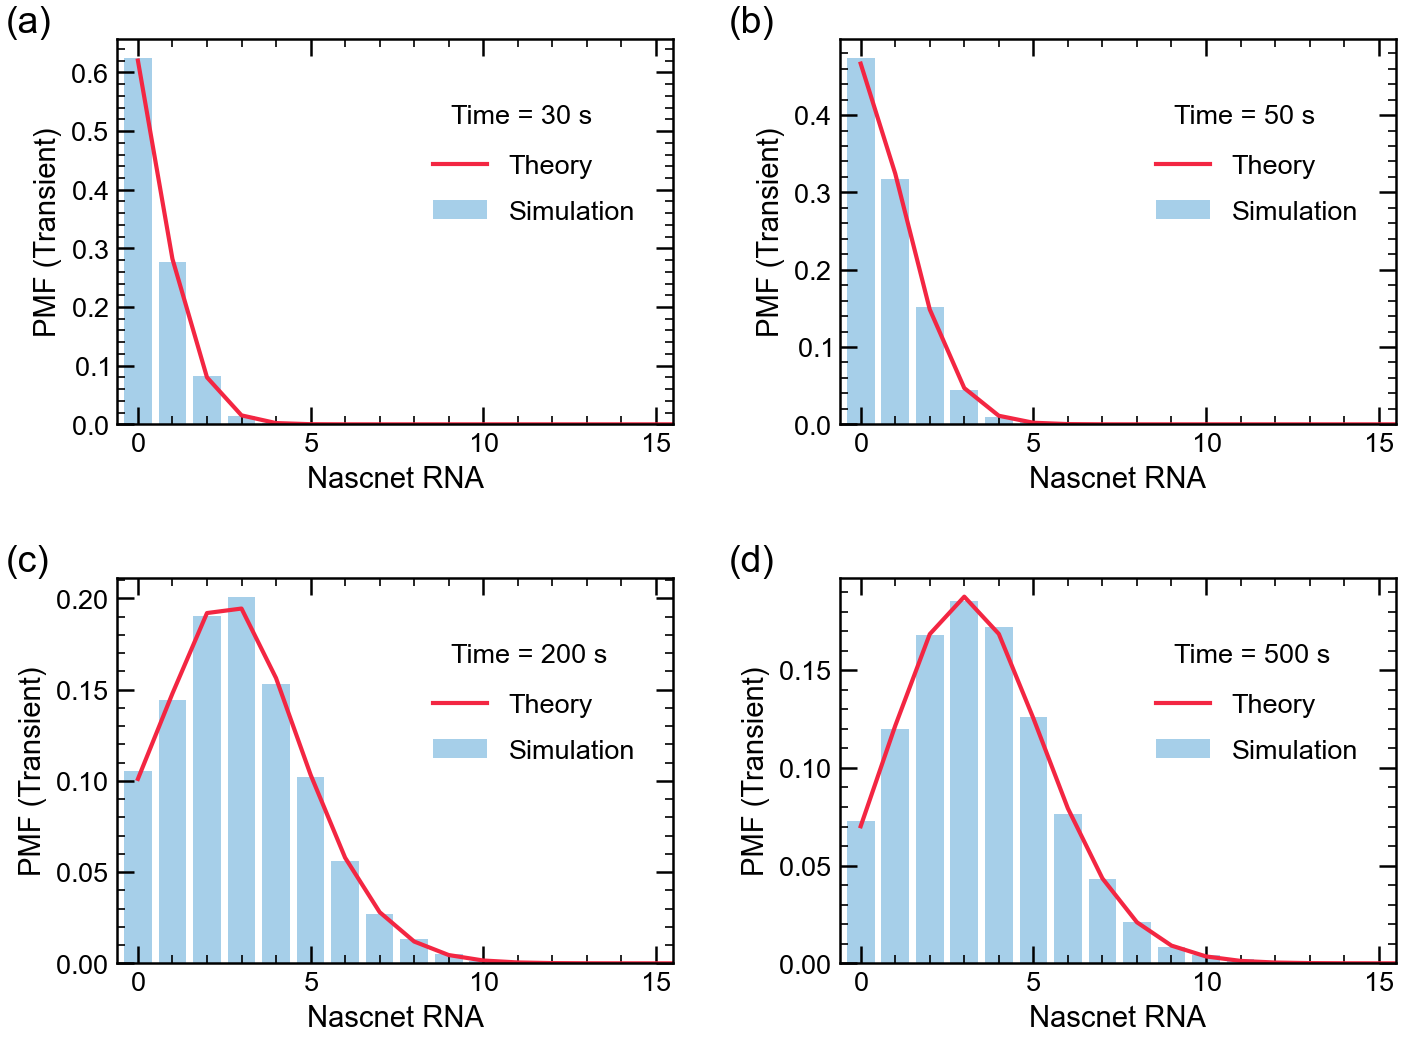

In [3]:

configure_journal_style()
fig, axes = plt.subplots(2, 2, figsize=(5.5,4))
axes = axes.ravel()

for ax, t, ti in zip(axes, times, idxs):

    Ns = N_mat[:, ti-1]                   
    maxN = int(max(Ns.max(), Nmax))
    bins = np.arange(0, maxN + 2) - 0.5
    hist, _ = np.histogram(Ns, bins=bins)
    emp_pmf = hist / max(hist.sum(), 1)

    p_the = p_nt[:, ti]                
    if len(p_the) < (maxN + 1):
        p_the = np.pad(p_the, (0, maxN + 1 - len(p_the)))

    ns = np.arange(0, maxN + 1)

    ax.bar(ns, emp_pmf, width=0.8, alpha=0.35, align="center",
           label="Simulation",color="#0277C0")
    ax.plot(ns, p_the[:maxN+1], linewidth=1, label="Theory", color="#F32642")
    ax.legend(labelspacing=0.8, loc='upper right', bbox_to_anchor=(1.00, 0.80))  
    ax.set_xlabel("Nascnet RNA")
    ax.set_ylabel("PMF (Transient)")
    ax.text(0.6, 0.77, f'Time = {int(t)} s', transform=ax.transAxes, fontsize=6.5, va='bottom', ha='left')
    

    ax.set_xlim(-0.6, 15+0.5)
    ax.set_ylim(0.0, max(0.05, 1.05*max(emp_pmf.max(), p_the[:maxN+1].max())))
    

plt.subplots_adjust(hspace=0.4, wspace=0.3)  


axes[0].text(-0.2, 1.00, '(a)', transform=axes[0].transAxes, fontsize=9, va='bottom', ha='left')
axes[1].text(-0.2, 1.00, '(b)', transform=axes[1].transAxes, fontsize=9, va='bottom', ha='left')
axes[2].text(-0.2, 1.00, '(c)', transform=axes[2].transAxes, fontsize=9, va='bottom', ha='left')
axes[3].text(-0.2, 1.00, '(d)', transform=axes[3].transAxes, fontsize=9, va='bottom', ha='left')
plt.savefig('Fig2.pdf', dpi=300, bbox_inches='tight')
plt.show()
